## Reasoning Input

In [1]:
import sys

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

MODEL_ID = "microsoft/Phi-3-mini-4k-instruct"

tok = AutoTokenizer.from_pretrained(MODEL_ID)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True
)
model.eval()

`torch_dtype` is deprecated! Use `dtype` instead!
`flash-attention` package not found, consider installing for better performance: No module named 'flash_attn'.
Current `flash-attention` does not support `window_size`. Either upgrade or use `attn_implementation='eager'`.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Phi3ForCausalLM(
  (model): Phi3Model(
    (embed_tokens): Embedding(32064, 3072, padding_idx=32000)
    (embed_dropout): Dropout(p=0.0, inplace=False)
    (layers): ModuleList(
      (0-31): 32 x Phi3DecoderLayer(
        (self_attn): Phi3Attention(
          (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (qkv_proj): Linear(in_features=3072, out_features=9216, bias=False)
          (rotary_emb): Phi3RotaryEmbedding()
        )
        (mlp): Phi3MLP(
          (gate_up_proj): Linear(in_features=3072, out_features=16384, bias=False)
          (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
          (activation_fn): SiLUActivation()
        )
        (input_layernorm): Phi3RMSNorm()
        (resid_attn_dropout): Dropout(p=0.0, inplace=False)
        (resid_mlp_dropout): Dropout(p=0.0, inplace=False)
        (post_attention_layernorm): Phi3RMSNorm()
      )
    )
    (norm): Phi3RMSNorm()
  )
  (lm_head): Linear(in_features=3072, out_fea

In [3]:
import torch
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1) PROMPT-GRUPPEN
# --------------------------------------------------
prompt_sets = {
    "reasoning": [
        "A bat and a ball cost 1.10 in total. The bat costs 1.00 more than the ball. How much does the ball cost?",
        "If all roses are flowers and some flowers fade quickly, can we conclude that some roses fade quickly? Explain briefly.",
        "A farmer has 17 sheep and all but 9 die. How many are left?"
    ],
    "causal": [
        "Explain why dropping a glass on the floor causes it to shatter.",
        "Why can removing a critical parameter reduce model performance?",
        "What usually happens if a car runs out of fuel while driving?"
    ],
    "math": [
        "Solve step by step: 27 * 14",
        "What is the derivative of x^2 + 3x + 1?",
        "If a train travels 120 km in 2 hours, what is its average speed?"
    ],
    "knowledge": [
        "What is the capital of France?",
        "Who developed the theory of relativity?",
        "What is photosynthesis?"
    ],
    "coding": [
        "Write a Python function that returns the factorial of a number.",
        "What does a for-loop do in Python?",
        "How do you reverse a list in Python?"
    ]
}

In [4]:
# --------------------------------------------------
# 2) HILFSFUNKTIONEN
# --------------------------------------------------
def get_transformer_layers(model):
    if hasattr(model, "model") and hasattr(model.model, "layers"):
        return model.model.layers
    raise ValueError("Could not find transformer layers. Inspect model structure with print(model).")


def get_down_proj_module(layer):
    if hasattr(layer, "mlp") and hasattr(layer.mlp, "down_proj"):
        return layer.mlp.down_proj
    if hasattr(layer, "mlp") and hasattr(layer.mlp, "fc2"):
        return layer.mlp.fc2
    raise ValueError("Could not find down projection module in this layer.")


def get_model_device(model):
    return next(model.parameters()).device


def make_layer_store(num_layers):
    return {
        i: {
            "in_max": None,
            "out_max": None,
        }
        for i in range(num_layers)
    }


def collect_for_layer(layer_idx, store):
    def hook_fn(module, inputs, outputs):
        x = inputs[0].detach()
        y = outputs.detach()

        x_abs = x.abs().reshape(-1, x.shape[-1])
        y_abs = y.abs().reshape(-1, y.shape[-1])

        x_max = x_abs.max(dim=0).values
        y_max = y_abs.max(dim=0).values

        if store[layer_idx]["in_max"] is None:
            store[layer_idx]["in_max"] = x_max
            store[layer_idx]["out_max"] = y_max
        else:
            store[layer_idx]["in_max"] = torch.maximum(store[layer_idx]["in_max"], x_max)
            store[layer_idx]["out_max"] = torch.maximum(store[layer_idx]["out_max"], y_max)

    return hook_fn

In [5]:
# --------------------------------------------------
# 3) HAUPTANALYSE: EIN FORWARD ÜBER ALLE LAYER-HOOKS
# --------------------------------------------------
def analyze_prompt_group_all_layers(model, tok, texts, title_prefix="Model", max_len=128):
    layers = get_transformer_layers(model)
    L = len(layers)

    store = make_layer_store(L)
    hooks = []

    for l in range(L):
        mod = get_down_proj_module(layers[l])
        hooks.append(mod.register_forward_hook(collect_for_layer(l, store)))

    device = get_model_device(model)

    try:
        with torch.no_grad():
            for t in texts:
                inp = tok(
                    t,
                    return_tensors="pt",
                    truncation=True,
                    max_length=max_len
                )
                inp = {k: v.to(device) for k, v in inp.items()}

                _ = model(
                    **inp,
                    use_cache=False,
                    output_attentions=False,
                    output_hidden_states=False,
                    return_dict=True
                )
    finally:
        for h in hooks:
            h.remove()

    in_vals, in_chs = [], []
    out_vals, out_chs = [], []

    for l in range(L):
        if store[l]["in_max"] is None or store[l]["out_max"] is None:
            raise RuntimeError(f"No activations collected for layer {l}")

        in_peak_val, in_peak_ch = store[l]["in_max"].max(dim=0)
        out_peak_val, out_peak_ch = store[l]["out_max"].max(dim=0)

        in_vals.append(float(in_peak_val.cpu()))
        in_chs.append(int(in_peak_ch.cpu()))
        out_vals.append(float(out_peak_val.cpu()))
        out_chs.append(int(out_peak_ch.cpu()))

    # Plot input spikes
    plt.figure(figsize=(8, 4))
    plt.plot(range(L), in_vals, marker="o")
    plt.title(f"{title_prefix}: Max |down_proj input| per layer")
    plt.xlabel("Layer")
    plt.ylabel("Max abs activation")
    plt.grid(True)
    plt.show()

    # Plot output spikes
    plt.figure(figsize=(8, 4))
    plt.plot(range(L), out_vals, marker="o")
    plt.title(f"{title_prefix}: Max |down_proj output| per layer")
    plt.xlabel("Layer")
    plt.ylabel("Max abs activation")
    plt.grid(True)
    plt.show()

    spike_layer = int(max(range(L), key=lambda i: out_vals[i]))
    candidate = (out_chs[spike_layer], in_chs[spike_layer])

    W = get_down_proj_module(layers[spike_layer]).weight.detach()

    print("Spike layer:", spike_layer)
    print("Input channel k:", in_chs[spike_layer])
    print("Output channel j:", out_chs[spike_layer])
    print("Candidate SW coordinate: down_proj.weight[j, k] =", candidate)
    print("Absolute candidate weight value:", float(W[candidate[0], candidate[1]].abs().cpu()))

    return {
        "in_vals": in_vals,
        "out_vals": out_vals,
        "in_chs": in_chs,
        "out_chs": out_chs,
        "spike_layer": spike_layer,
        "candidate_coord": candidate,
        "candidate_abs_weight": float(W[candidate[0], candidate[1]].abs().cpu()),
    }

You are not running the flash-attention implementation, expect numerical differences.


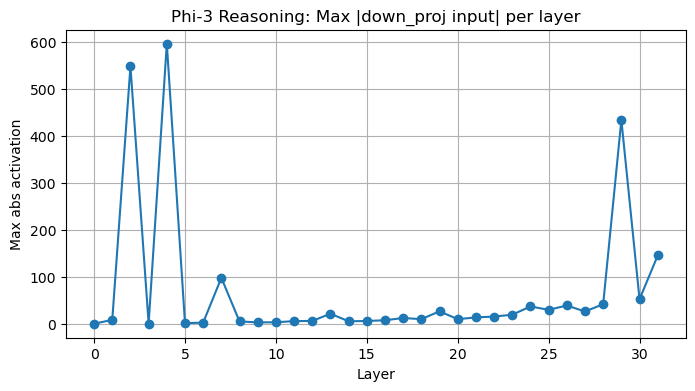

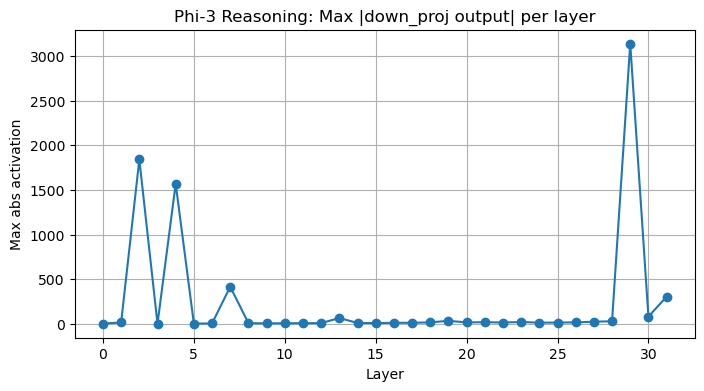

Spike layer: 29
Input channel k: 4800
Output channel j: 525
Candidate SW coordinate: down_proj.weight[j, k] = (525, 4800)
Absolute candidate weight value: 2.765625


In [6]:
# --------------------------------------------------
# 4) EINZELNE KATEGORIE TESTEN
# --------------------------------------------------
reasoning_result = analyze_prompt_group_all_layers(
    model,
    tok,
    prompt_sets["reasoning"],
    title_prefix="Phi-3 Reasoning",
    max_len=128
)

In [8]:
math_texts_small = [
    "Solve step by step: 27 * 14"
]

In [ ]:
math_result = analyze_prompt_group_all_layers(
    model,
    tok,
    math_texts_small,
    title_prefix="Phi-3 Math",
    max_len=128
)

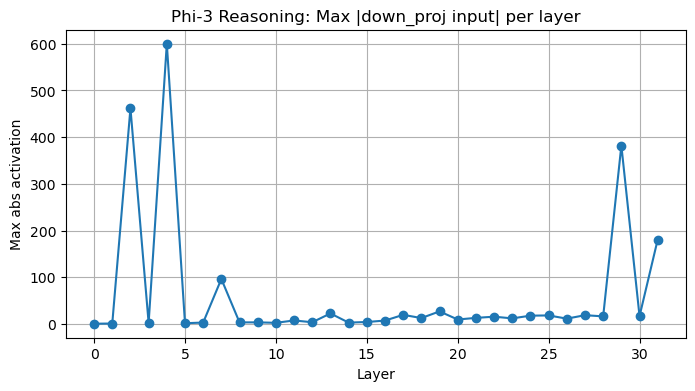

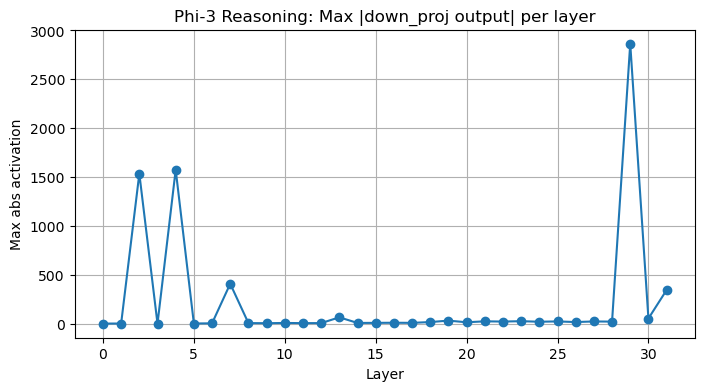

Spike layer: 29
Input channel k: 4800
Output channel j: 525
Candidate SW coordinate: down_proj.weight[j, k] = (525, 4800)
Absolute candidate weight value: 2.765625


In [7]:
reasoning_result = analyze_prompt_group_all_layers(
    model,
    tok,
    prompt_sets["knowledge"],
    title_prefix="Phi-3 Reasoning",
    max_len=128
)

In [ ]:
reasoning_result = analyze_prompt_group_all_layers(
    model,
    tok,
    prompt_sets["coding"],
    title_prefix="Phi-3 Reasoning",
    max_len=128
)

## OLMo-1B

In [1]:
import json
from pathlib import Path
import pandas as pd

rows = []

for path in sorted(Path("../../results/activation_scan/olmo1b").glob("*.json")):
    data = json.load(open(path))
    rows.append({
        "category": path.stem,
        "spike_layer": data["spike_layer"],
        "candidate_j": data["candidate_coord"][0],
        "candidate_k": data["candidate_coord"][1],
        "candidate_abs_weight": data["candidate_abs_weight"],
        "max_out_at_spike": data["out_vals"][data["spike_layer"]],
    })

summary_df = pd.DataFrame(rows).sort_values("category")
summary_df

,category,spike_layer,candidate_j,candidate_k,candidate_abs_weight,max_out_at_spike
0,causal,15,1764,6840,0.726074,423.00
1,coding,15,1764,6840,0.726074,423.00
2,knowledge,15,1764,6840,0.726074,432.25
3,math,15,1764,6840,0.726074,413.25
4,reasoning,15,1764,6840,0.726074,426.50


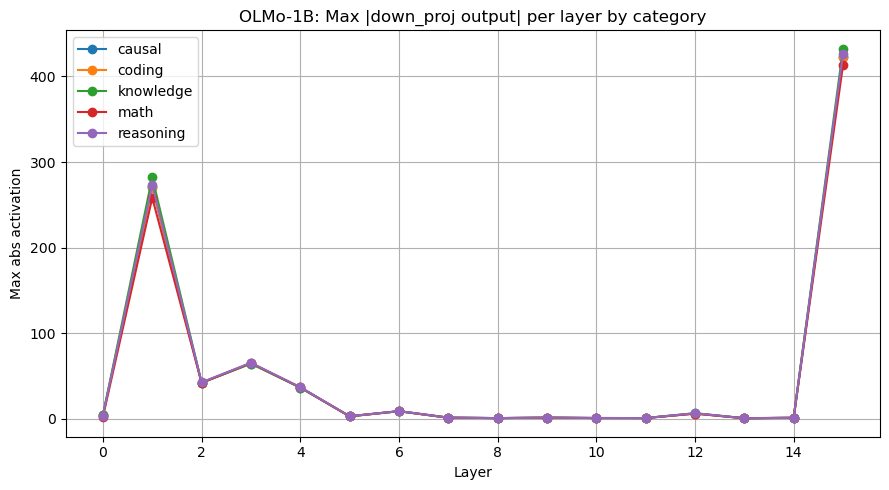

In [2]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

for path in sorted(Path("../../results/activation_scan/olmo1b").glob("*.json")):
    data = json.load(open(path))
    plt.plot(data["out_vals"], marker="o", label=path.stem)

plt.title("OLMo-1B: Max |down_proj output| per layer by category")
plt.xlabel("Layer")
plt.ylabel("Max abs activation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

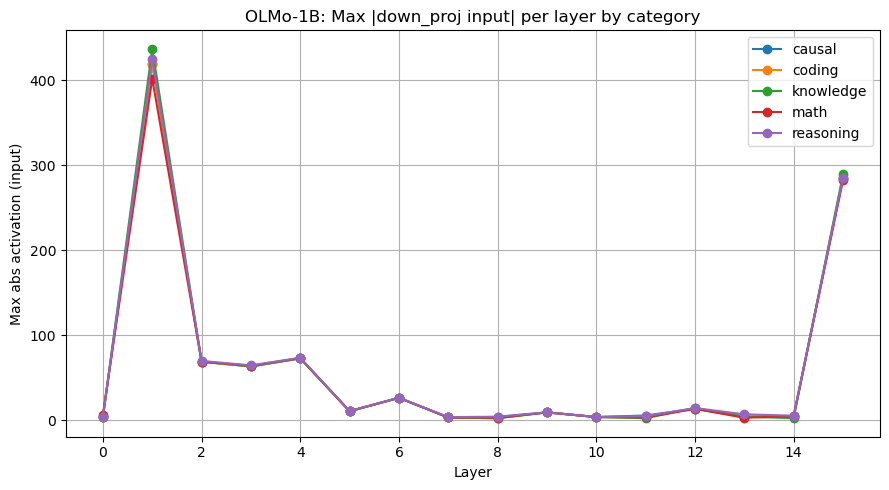

In [3]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

base_path = Path("../../results/activation_scan/olmo1b")

plt.figure(figsize=(9, 5))

for path in sorted(base_path.glob("*.json")):
    data = json.load(open(path))
    
    plt.plot(
        data["in_vals"],
        marker="o",
        label=path.stem
    )

plt.title("OLMo-1B: Max |down_proj input| per layer by category")
plt.xlabel("Layer")
plt.ylabel("Max abs activation (input)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

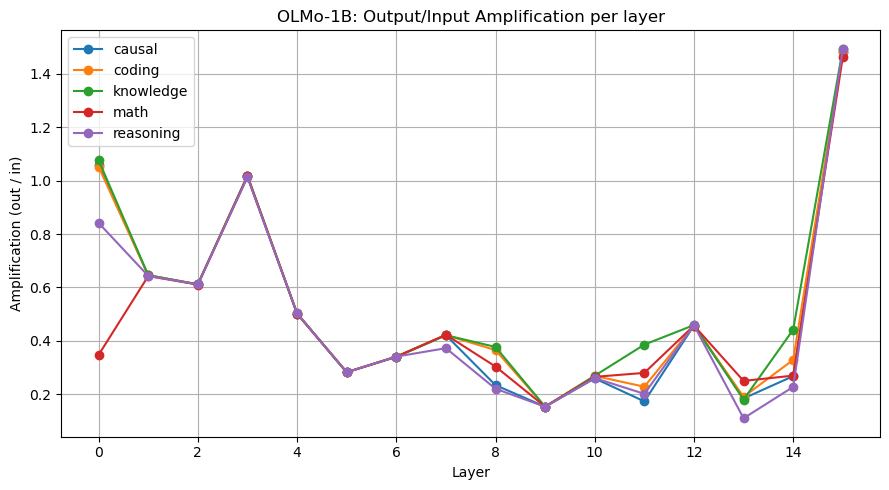

In [4]:
plt.figure(figsize=(9,5))

for path in sorted(base_path.glob("*.json")):
    data = json.load(open(path))
    
    ratio = [
        o / (i + 1e-6)
        for o, i in zip(data["out_vals"], data["in_vals"])
    ]
    
    plt.plot(ratio, marker="o", label=path.stem)

plt.title("OLMo-1B: Output/Input Amplification per layer")
plt.xlabel("Layer")
plt.ylabel("Amplification (out / in)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

MODEL_ID = "mistralai/Mistral-7B-v0.1"

tok = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto"
)
model.eval()

print(model)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


MistralForCausalLM(
  (model): MistralModel(
    (embed_tokens): Embedding(32000, 4096)
    (layers): ModuleList(
      (0-31): 32 x MistralDecoderLayer(
        (self_attn): MistralAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): MistralMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): MistralRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): MistralRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): MistralRMSNorm((4096,)